In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import HDBSCAN

# 1. Load
df = pd.read_csv('../data/violations.csv', low_memory=False)

# 2. Datetime + IST conversion
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601')
df['created_datetime_ist'] = df['created_datetime'] + pd.Timedelta(hours=5, minutes=30)
df['hour'] = df['created_datetime_ist'].dt.hour
df['day_of_week'] = df['created_datetime_ist'].dt.day_name()

# 3. Check columns
print(df.columns.tolist())
print(df.shape)

['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp', 'created_datetime_ist', 'hour', 'day_of_week']
(298450, 27)


In [2]:
import json

df['violation_type_list'] = df['violation_type'].apply(json.loads)
df['violation_type_list'].iloc[0]

['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']

In [3]:
df['offence_code_list'] = df['offence_code'].apply(json.loads)
df['offence_code_list'].iloc[0]

[112, 104]

In [4]:
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601')
df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.day_name()

df[['created_datetime', 'hour', 'day_of_week']].head()

,created_datetime,hour,day_of_week
0,2023-11-20 00:28:46+00:00,0,Monday
1,2023-11-24 22:46:46+00:00,22,Friday
2,2023-11-20 00:27:46+00:00,0,Monday
3,2023-11-16 06:47:46+00:00,6,Thursday
4,2023-11-22 04:56:46+00:00,4,Wednesday


In [5]:
confidence_map = {
    'approved': 1.0,
    'processing': 0.5,
    'created1': 0.5,
    'rejected': 0.0,
    'duplicate': 0.0
}

df['confidence_weight'] = df['validation_status'].map(confidence_map)
df['confidence_weight'] = df['confidence_weight'].fillna(0.5)

df['confidence_weight'].value_counts()

confidence_weight
0.5    132976
1.0    115400
0.0     50074
Name: count, dtype: int64

In [6]:
severity_map = {
    # High – directly blocks a road, junction, or oncoming traffic
    'PARKING IN A MAIN ROAD': 3,
    'DOUBLE PARKING': 3,
    'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS': 3,
    'OBSTRUCTING DRIVER': 3,
    'AGAINST ONE WAY/NO ENTRY': 3,
    'STOPING ON WHITE/STOP LINE': 3,

    # Medium – parking-related obstruction, but less central to flow
    'WRONG PARKING': 2,
    'NO PARKING': 2,
    'PARKING NEAR ROAD CROSSING': 2,
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC': 2,
    'PARKING ON FOOTPATH': 2,
    'PARKING OTHER THAN BUS STOP': 2,
    'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE': 2,
    'VIOLATING LANE DISIPLINE': 2,
    'U TURN PROHIBITED': 2,
    'H T V PROHIBITED': 2,
    'JUMPING TRAFFIC SIGNAL': 2,

    # Not congestion-related – safety/regulatory, unrelated to road obstruction
    'DEFECTIVE NUMBER PLATE': 0,
    'RIDER NOT WEARING HELMET': 0,
    'FAIL TO USE SAFETY BELTS': 0,
    '2W/3W - USING MOBILE PHONE': 0,
    'OTHER - USING MOBILE PHONE': 0,
    'DEMANDING EXCESS FARE': 0,
    'REFUSE TO GO FOR HIRE': 0,
    'CARRYING LENGHTY MATERIAL': 0,
    'USING BLACK FILM/OTHER MATERIALS': 0,
    'WITHOUT SIDE MIRROR': 0,
}

def get_severity(tags):
    return max(severity_map.get(tag, 0) for tag in tags)

df['severity_weight'] = df['violation_type_list'].apply(get_severity)
df['severity_weight'].value_counts()

severity_weight
2    273052
3     25398
Name: count, dtype: int64

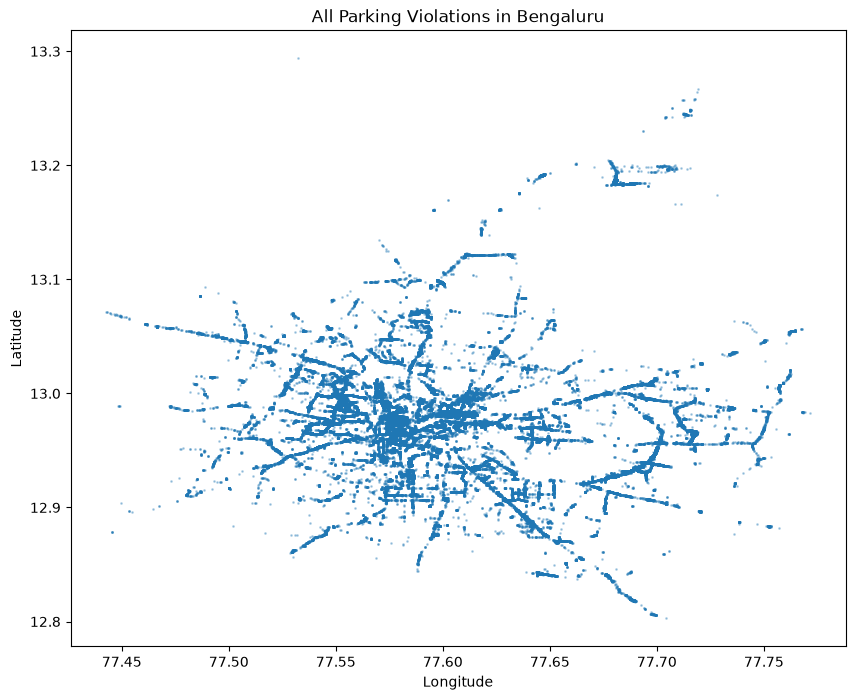

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(df['longitude'], df['latitude'], s=1, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Parking Violations in Bengaluru')
plt.show()

In [8]:
coords_rad = np.radians(df[['latitude', 'longitude']].values)

In [9]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=20, metric='haversine', copy=True)
df['cluster'] = hdb.fit_predict(coords_rad)

print("Number of clusters found:", len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0))
print("Number of noise points:", (df['cluster'] == -1).sum())

cluster_sizes = df[df['cluster'] != -1]['cluster'].value_counts()
print(cluster_sizes.head(10))

Number of clusters found: 2063
Number of noise points: 87092
cluster
375     3291
1821    2940
1422    2594
1460    2504
2030    1972
954     1781
341     1624
1797    1596
1454    1535
1575    1526
Name: count, dtype: int64


In [10]:
import pandas as pd
import numpy as np
from sklearn.cluster import HDBSCAN

# 1. Load
df = pd.read_csv('../data/violations.csv')

# 2. Datetime + IST conversion
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601')
df['created_datetime_ist'] = df['created_datetime'] + pd.Timedelta(hours=5, minutes=30)
df['hour'] = df['created_datetime_ist'].dt.hour
df['day_of_week'] = df['created_datetime_ist'].dt.day_name()

# 3. Check columns
print(df.columns.tolist())
print(df.shape)

['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp', 'created_datetime_ist', 'hour', 'day_of_week']
(298450, 27)


In [11]:
# 4. Severity weight — based on presence of high-impact violation types
high_severity = ['PARKING IN A MAIN ROAD', 'DOUBLE PARKING', 
                 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS',
                 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC',
                 'PARKING NEAR ROAD CROSSING']

def compute_severity(vtype):
    score = 0.5  # base score for any violation
    for h in high_severity:
        if h in str(vtype):
            score += 0.1  # add 0.1 per high-severity tag present
    return min(score, 1.0)  # cap at 1.0

df['severity_weight'] = df['violation_type'].apply(compute_severity)

# 5. Confidence weight from validation_status
confidence_map = {
    'approved':    1.0,
    'processing':  0.7,
    'created1':    0.5,
    'rejected':    0.1,
    'duplicate':   0.1
}
df['confidence_weight'] = df['validation_status'].map(confidence_map).fillna(0.5)

print(df[['violation_type', 'severity_weight', 'validation_status', 'confidence_weight']].head(5))
print("\nseverity_weight distribution:\n", df['severity_weight'].value_counts().head())
print("\nconfidence_weight distribution:\n", df['confidence_weight'].value_counts())

                                   violation_type  severity_weight  \
0  ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]              0.6   
1                                  ["NO PARKING"]              0.5   
2      ["WRONG PARKING","PARKING IN A MAIN ROAD"]              0.6   
3                                  ["NO PARKING"]              0.5   
4                                  ["NO PARKING"]              0.5   

  validation_status  confidence_weight  
0          approved                1.0  
1               NaN                0.5  
2          approved                1.0  
3          approved                1.0  
4          approved                1.0  

severity_weight distribution:
 severity_weight
0.5    271037
0.6     24815
0.7      2112
0.8       405
0.9        64
Name: count, dtype: int64

confidence_weight distribution:
 confidence_weight
0.5    132298
1.0    115400
0.1     50074
0.7       678
Name: count, dtype: int64


In [12]:
# 6. Cluster
coords_rad = np.radians(df[['latitude', 'longitude']].values)
hdb = HDBSCAN(min_cluster_size=20, metric='haversine', copy=True)
df['cluster'] = hdb.fit_predict(coords_rad)

# 7. Build clustered_df
clustered_df = df[df['cluster'] != -1].copy()

# 8. Cluster summary
cluster_summary = clustered_df.groupby('cluster').agg(
    raw_count=('cluster', 'size'),
    weighted_count=('confidence_weight', 'sum'),
    avg_severity=('severity_weight', 'mean'),
    distinct_days=('created_datetime_ist', lambda x: x.dt.date.nunique()),
    centroid_lat=('latitude', 'mean'),
    centroid_lon=('longitude', 'mean'),
    police_station=('police_station', lambda x: x.mode()[0] if not x.mode().empty else None),
    junction_name=('junction_name', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()

print(cluster_summary.shape)
cluster_summary.sort_values('weighted_count', ascending=False).head(10)

(2063, 9)


,cluster,raw_count,weighted_count,avg_severity,distinct_days,centroid_lat,centroid_lon,police_station,junction_name
375,375,3291,1888.3,0.526253,149,13.008260,77.695191,K.R. Pura,No Junction
1422,1422,2594,1736.6,0.500039,138,13.007300,77.571055,Malleshwaram,No Junction
1460,1460,2504,1564.4,0.502875,129,12.984076,77.603523,Shivajinagar,BTP211 - Central Street Junction
1821,1821,2940,1519.0,0.507721,129,12.981044,77.610226,Shivajinagar,BTP051 - Safina Plaza Junction
2030,2030,1972,1332.0,0.501166,127,12.976220,77.577363,Upparpet,BTP040 - Elite Junction
954,954,1781,1097.2,0.500168,122,13.035358,77.589052,Hebbala,No Junction
1454,1454,1535,986.2,0.501303,81,12.964875,77.538857,Vijayanagara,"BTP016 - 5th Main Road, RPC Layout"
1797,1797,1596,980.2,0.503195,138,12.981519,77.608472,Shivajinagar,BTP051 - Safina Plaza Junction
1575,1575,1526,922.4,0.500721,85,12.973484,77.551098,Magadi Road,"BTP070 - Cholurpalya Junction, Magadi Road"
1974,1974,1315,896.6,0.504867,123,12.979845,77.574921,Upparpet,BTP057 - Anand Rao Junction


In [14]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the three components to 0-1
scaler = MinMaxScaler()
cluster_summary[['norm_count', 'norm_severity', 'norm_days']] = scaler.fit_transform(
    cluster_summary[['weighted_count', 'avg_severity', 'distinct_days']]
)

# Composite impact score (out of 100)
# 50% weight on violation density, 30% on recurrence, 20% on severity
cluster_summary['impact_score'] = (
    0.5 * cluster_summary['norm_count'] +
    0.3 * cluster_summary['norm_days'] +
    0.2 * cluster_summary['norm_severity']
) * 100

# Priority ranking
priority_queue = cluster_summary.sort_values('impact_score', ascending=False).reset_index(drop=True)
priority_queue['rank'] = priority_queue.index + 1

priority_queue[['rank', 'impact_score', 'police_station', 'junction_name',
                'centroid_lat', 'centroid_lon', 'raw_count',
                'distinct_days', 'avg_severity']].head(20)

,rank,impact_score,police_station,junction_name,centroid_lat,centroid_lon,raw_count,distinct_days,avg_severity
0,1,81.827586,K.R. Pura,No Junction,13.008260,77.695191,3291,149,0.526253
1,2,73.749295,Malleshwaram,No Junction,13.007300,77.571055,2594,138,0.500039
2,3,67.555056,Shivajinagar,BTP211 - Central Street Junction,12.984076,77.603523,2504,129,0.502875
3,4,66.688200,Shivajinagar,BTP051 - Safina Plaza Junction,12.981044,77.610226,2940,129,0.507721
4,5,60.866547,Upparpet,BTP040 - Elite Junction,12.976220,77.577363,1972,127,0.501166
5,6,54.528344,Mahadevapura,No Junction,12.996213,77.668536,1624,126,0.580296
6,7,53.906463,Shivajinagar,BTP051 - Safina Plaza Junction,12.981519,77.608472,1596,138,0.503195
7,8,53.555781,Hebbala,No Junction,13.035358,77.589052,1781,122,0.500168
8,9,48.764888,Upparpet,BTP057 - Anand Rao Junction,12.979845,77.574921,1315,123,0.504867
9,10,45.448441,Halasuru Gate,"BTP080 - NR Road, SP Road Junction",12.964669,77.584029,1486,110,0.504643


In [15]:
import os
os.makedirs('../outputs', exist_ok=True)

priority_queue[['rank', 'impact_score', 'police_station', 'junction_name',
                'centroid_lat', 'centroid_lon', 'raw_count',
                'distinct_days', 'avg_severity']].to_json(
    '../outputs/priority_queue.json',
    orient='records',
    indent=2
)
print("Exported successfully")

Exported successfully


In [16]:
import folium
import os

os.makedirs('../outputs', exist_ok=True)

m = folium.Map(location=[12.9716, 77.5946], zoom_start=12)

top20 = priority_queue.head(20)

for _, row in top20.iterrows():
    folium.CircleMarker(
        location=[row['centroid_lat'], row['centroid_lon']],
        radius=10 + row['impact_score'] / 10,
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"Rank #{int(row['rank'])}<br>"
            f"Score: {row['impact_score']:.1f}<br>"
            f"Station: {row['police_station']}<br>"
            f"Junction: {row['junction_name']}<br>"
            f"Violations: {int(row['raw_count'])}<br>"
            f"Active Days: {int(row['distinct_days'])}",
            max_width=250
        )
    ).add_to(m)

m.save('../outputs/hotspot_map.html')
print("Map saved")

Map saved


In [17]:
# Step: build additional independent features per cluster, distinct from the
# scoring formula's own inputs (weighted_count, avg_severity, distinct_days),
# so LightGBM has to genuinely learn signal rather than just re-deriving the formula.

extra_features = clustered_df.groupby('cluster').agg(
    n_unique_devices=('device_id', 'nunique'),
    n_unique_vehicles=('vehicle_number', 'nunique'),
    pct_approved=('confidence_weight', lambda x: (x == 1.0).mean()),
    pct_weekend=('day_of_week', lambda x: x.isin(['Saturday', 'Sunday']).mean()),
    mode_hour=('hour', lambda x: x.mode()[0] if not x.mode().empty else -1),
    hour_std=('hour', 'std'),
).reset_index()

feature_table = cluster_summary.merge(extra_features, on='cluster')
print(feature_table.shape)
feature_table.head(10)

(2063, 19)


,cluster,raw_count,weighted_count,avg_severity,distinct_days,centroid_lat,centroid_lon,police_station,junction_name,norm_count,norm_severity,norm_days,impact_score,n_unique_devices,n_unique_vehicles,pct_approved,pct_weekend,mode_hour,hour_std
0,0,20,6.9,0.550000,8,13.161680,77.596286,Chikkajala,No Junction,0.001963,0.174033,0.047297,4.997720,5,20,0.050000,0.700000,11,2.661124
1,1,86,54.2,0.512791,30,13.244788,77.713250,Devanahalli Airport,No Junction,0.027054,0.044520,0.195946,8.121494,15,85,0.279070,0.186047,4,2.504087
2,2,22,14.0,0.504545,11,13.248408,77.715587,Devanahalli Airport,No Junction,0.005729,0.015821,0.067568,2.629908,8,21,0.454545,0.227273,5,3.006846
3,3,20,8.0,0.655000,8,12.887385,77.738477,No Police Station,No Junction,0.002546,0.539503,0.047297,12.336288,4,15,0.200000,0.100000,5,3.160613
4,4,54,25.0,0.529630,32,12.883555,77.752335,No Police Station,No Junction,0.011564,0.103131,0.209459,8.924618,13,53,0.148148,0.500000,4,3.606230
5,5,155,89.1,0.517419,34,13.144014,77.617994,Chikkajala,No Junction,0.045568,0.060631,0.222973,10.180201,13,150,0.309677,0.225806,1,5.192588
6,6,29,17.1,0.527586,11,13.161280,77.626529,Chikkajala,No Junction,0.007374,0.096018,0.067568,4.316074,8,29,0.344828,0.034483,2,5.074567
7,7,111,57.0,0.500901,27,13.197440,77.703641,Devanahalli Airport,No Junction,0.028540,0.003136,0.175676,6.759965,12,103,0.279279,0.081081,11,3.486584
8,8,229,131.9,0.563319,84,13.045871,77.750262,K.R. Pura,No Junction,0.068272,0.220391,0.560811,24.645763,21,221,0.358079,0.318777,11,3.702297
9,9,108,73.9,0.558333,34,13.035384,77.735211,K.R. Pura,No Junction,0.037505,0.203039,0.222973,12.625195,11,103,0.546296,0.250000,2,3.997262


In [18]:
from sklearn.model_selection import train_test_split

# Encode categoricals as pandas 'category' dtype - LightGBM uses this natively
feature_table['police_station'] = feature_table['police_station'].astype('category')
feature_table['junction_name'] = feature_table['junction_name'].astype('category')

# Features deliberately EXCLUDE weighted_count, avg_severity, distinct_days,
# norm_count, norm_severity, norm_days - those are the scoring formula's direct
# inputs/outputs. Using them would let the model trivially recover the formula
# rather than genuinely learn from independent signal.
feature_cols = [
    'raw_count', 'centroid_lat', 'centroid_lon', 'police_station', 'junction_name',
    'n_unique_devices', 'n_unique_vehicles', 'pct_approved', 'pct_weekend',
    'mode_hour', 'hour_std'
]
target_col = 'impact_score'

X = feature_table[feature_cols]
y = feature_table[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1650, 11)
Test shape: (413, 11)


In [19]:
import lightgbm as lgb
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_absolute_error

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=['police_station', 'junction_name'])
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=['police_station', 'junction_name'], reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'seed': 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(0)]
)

y_pred = model.predict(X_test, num_iteration=model.best_iteration)

corr, p_value = pearsonr(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Pearson correlation: {corr:.4f}  (p-value: {p_value:.2e})")
print(f"R² score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Best iteration: {model.best_iteration}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[62]	valid_0's rmse: 2.42357
Pearson correlation: 0.9334  (p-value: 5.34e-185)
R² score: 0.8668
MAE: 1.5588
Best iteration: 62


In [20]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(importance)

              feature     importance
6   n_unique_vehicles  357437.302225
0           raw_count   58244.189631
5    n_unique_devices   21006.768169
2        centroid_lon    5629.508844
7        pct_approved    5070.793085
8         pct_weekend    3855.522055
10           hour_std    3698.571521
1        centroid_lat    3689.255058
3      police_station    3310.399712
9           mode_hour    1580.379789
4       junction_name     152.699030


In [21]:
feature_cols_strict = [
    'centroid_lat', 'centroid_lon', 'police_station', 'junction_name',
    'n_unique_devices', 'n_unique_vehicles', 'pct_approved', 'pct_weekend',
    'mode_hour', 'hour_std'
]

X_strict = feature_table[feature_cols_strict]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_strict, y, test_size=0.2, random_state=42)

train_data_s = lgb.Dataset(X_train_s, label=y_train_s, categorical_feature=['police_station', 'junction_name'])
test_data_s = lgb.Dataset(X_test_s, label=y_test_s, categorical_feature=['police_station', 'junction_name'], reference=train_data_s)

model_strict = lgb.train(
    params,
    train_data_s,
    num_boost_round=200,
    valid_sets=[test_data_s],
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(0)]
)

y_pred_s = model_strict.predict(X_test_s, num_iteration=model_strict.best_iteration)

corr_s, p_s = pearsonr(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"Pearson correlation (no raw_count): {corr_s:.4f}  (p-value: {p_s:.2e})")
print(f"R² score (no raw_count): {r2_s:.4f}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[38]	valid_0's rmse: 2.46588
Pearson correlation (no raw_count): 0.9317  (p-value: 6.60e-183)
R² score (no raw_count): 0.8621


In [22]:
# Save cluster_summary so queue_service.py can load it
cluster_summary.to_json("../model/cluster_summary.json", orient="records")
print("✅ cluster_summary saved to ../model/cluster_summary.json")

✅ cluster_summary saved to ../model/cluster_summary.json


In [23]:
import os
os.makedirs("../model", exist_ok=True)
model.save_model("../model/model.txt")
cluster_summary.to_json("../model/cluster_summary.json", orient="records")
print("Current dir:", os.getcwd())
print("Files in ../model/:", os.listdir("../model"))

Current dir: /Users/pranavpratapbobade/Desktop/parksight-ml/notebook
Files in ../model/: ['model.txt', 'cluster_summary.json']


In [24]:
import requests

top = feature_table.nlargest(1, "impact_score").iloc[0]

payload = {
    "cluster_id":        int(top["cluster"]),
    "raw_count":         float(top["raw_count"]),
    "centroid_lat":      float(top["centroid_lat"]),
    "centroid_lon":      float(top["centroid_lon"]),
    "police_station":    str(top["police_station"]),
    "junction_name":     str(top["junction_name"]),
    "n_unique_devices":  float(top["n_unique_devices"]),
    "n_unique_vehicles": float(top["n_unique_vehicles"]),
    "pct_approved":      float(top["pct_approved"]),
    "pct_weekend":       float(top["pct_weekend"]),
    "mode_hour":         float(top["mode_hour"]),
    "hour_std":          float(top["hour_std"]),
}

response = requests.post("http://localhost:8000/score", json=payload)
result = response.json()

print(f"Cluster ID:      {result['cluster_id']}")
print(f"Impact Score:    {result['predicted_impact_score']}")
print(f"Priority Tier:   {result['priority_tier']}")
print(f"Police Station:  {payload['police_station']}")
print(f"Raw Count:       {payload['raw_count']}")

Cluster ID:      375
Impact Score:    53.9544
Priority Tier:   MEDIUM
Police Station:  K.R. Pura
Raw Count:       3291.0


In [25]:
feature_table.to_json("../model/cluster_summary.json", orient="records")
print("✅ Saved to ../model/cluster_summary.json")
print(f"Total clusters saved: {len(feature_table)}")

✅ Saved to ../model/cluster_summary.json
Total clusters saved: 2063


In [26]:
from kafka import KafkaProducer
import json

producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

top_zones = priority_queue.head(10)

for _, row in top_zones.iterrows():
    message = {
        'cluster_id': int(row['cluster']),
        'rank': int(row['rank']),
        'impact_score': round(float(row['impact_score']), 4),
        'raw_count': int(row['raw_count']),
        'distinct_days': int(row['distinct_days']),
        'centroid_lat': float(row['centroid_lat']),
        'centroid_lon': float(row['centroid_lon']),
        'police_station': str(row['police_station']),
        'junction_name': str(row['junction_name'])
    }
    producer.send('violation-events', value=message)
    print(f"Published rank={message['rank']} | cluster={message['cluster_id']} | score={message['impact_score']} | {message['police_station']}")

producer.flush()
producer.close()
print("\nAll messages published.")

Published rank=1 | cluster=375 | score=81.8276 | K.R. Pura
Published rank=2 | cluster=1422 | score=73.7493 | Malleshwaram
Published rank=3 | cluster=1460 | score=67.5551 | Shivajinagar
Published rank=4 | cluster=1821 | score=66.6882 | Shivajinagar
Published rank=5 | cluster=2030 | score=60.8665 | Upparpet
Published rank=6 | cluster=341 | score=54.5283 | Mahadevapura
Published rank=7 | cluster=1797 | score=53.9065 | Shivajinagar
Published rank=8 | cluster=954 | score=53.5558 | Hebbala
Published rank=9 | cluster=1974 | score=48.7649 | Upparpet
Published rank=10 | cluster=1803 | score=45.4484 | Halasuru Gate

All messages published.


In [27]:
from kafka import KafkaConsumer

consumer = KafkaConsumer(
    'violation-events',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',
    value_deserializer=lambda v: json.loads(v.decode('utf-8')),
    consumer_timeout_ms=3000
)

print("Top priority violation zones from Kafka:\n")
for msg in consumer:
    d = msg.value
    print(f"Rank {d['rank']:>2} | Cluster {d['cluster_id']:>4} | Score: {d['impact_score']:>8.4f} | {d['police_station']} | {d['junction_name']}")

consumer.close()
print("\nDone.")

Top priority violation zones from Kafka:

Rank  1 | Cluster  375 | Score:  81.8276 | K.R. Pura | No Junction
Rank  2 | Cluster 1422 | Score:  73.7493 | Malleshwaram | No Junction
Rank  3 | Cluster 1460 | Score:  67.5551 | Shivajinagar | BTP211 - Central Street Junction
Rank  4 | Cluster 1821 | Score:  66.6882 | Shivajinagar | BTP051 - Safina Plaza Junction
Rank  5 | Cluster 2030 | Score:  60.8665 | Upparpet | BTP040 - Elite Junction
Rank  6 | Cluster  341 | Score:  54.5283 | Mahadevapura | No Junction
Rank  7 | Cluster 1797 | Score:  53.9065 | Shivajinagar | BTP051 - Safina Plaza Junction
Rank  8 | Cluster  954 | Score:  53.5558 | Hebbala | No Junction
Rank  9 | Cluster 1974 | Score:  48.7649 | Upparpet | BTP057 - Anand Rao Junction
Rank 10 | Cluster 1803 | Score:  45.4484 | Halasuru Gate | BTP080 - NR Road, SP Road Junction
Rank  1 | Cluster  375 | Score:  81.8276 | K.R. Pura | No Junction
Rank  2 | Cluster 1422 | Score:  73.7493 | Malleshwaram | No Junction
Rank  3 | Cluster 1460 | S